In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv("Medical_Risk_Classification.csv")
df.head()

,Biomarker_A,Biomarker_B,BMI,Age,Smoking_Status,Family_History,BMI_Squared,Age_Normalized,High_Risk
0,1.572821,0.719531,20.921853,76.852031,Non-Smoker,Yes,437.723931,0.960650,1
1,0.421854,1.924399,19.006796,41.350755,Current,No,361.258302,0.516884,1
2,3.425030,5.205850,19.791748,34.992573,Non-Smoker,Yes,391.713285,0.437407,1
3,3.538766,1.395408,21.139071,56.973044,Current,Yes,446.860330,0.712163,1
4,1.799962,3.646175,23.798603,49.932369,Non-Smoker,No,566.373523,0.624155,0


In [4]:
df=pd.get_dummies(df, drop_first=True)

NameError: name 'df' is not defined

In [4]:
df = df.drop(["BMI_Squared", "Age_Normalized"], axis=1, errors='ignore')

In [5]:
X = df.drop("High_Risk", axis=1)
Y = df["High_Risk"]

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

NameError: name 'X' is not defined

In [16]:
dummy=DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)
print('Baseline Accuracy:', accuracy_score(Y_test, dummy.predict(X_test)))

Baseline Accuracy: 0.855


In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [8]:
param_grid = {
    'knn__n_neighbors': list(range(1, 21)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, Y_train)
grid.best_params_

{'knn__n_neighbors': 4, 'knn__p': 1, 'knn__weights': 'distance'}

In [11]:
best_model = grid.best_estimator_
Y_pred = best_model.predict(X_test)

In [12]:
result=confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix")
print(result)
result1=classification_report(Y_test, Y_pred)
print("Classification Report:",)
print(result1)
result2=accuracy_score(Y_test, Y_pred)
print(result2)

Confusion Matrix
[[ 13  16]
 [  5 166]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.45      0.55        29
           1       0.91      0.97      0.94       171

    accuracy                           0.90       200
   macro avg       0.82      0.71      0.75       200
weighted avg       0.88      0.90      0.88       200

0.895


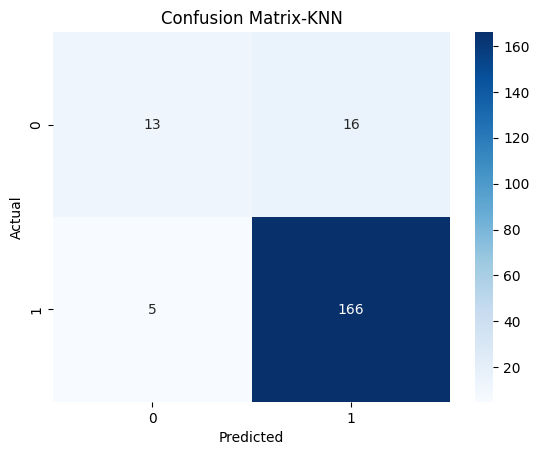

In [13]:
cm=confusion_matrix(Y_test, Y_pred)
plt.figure()
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix-KNN")
plt.show()

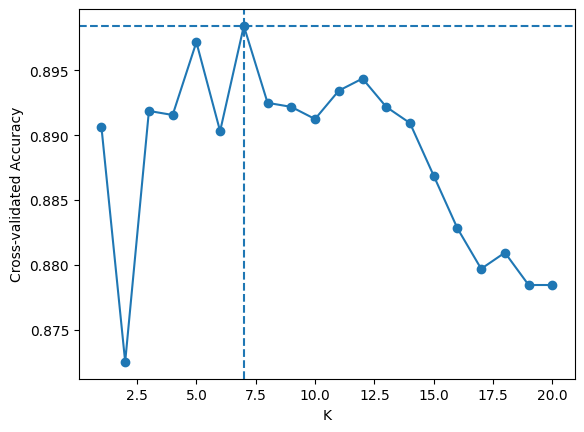


Optimal k: 7
0.8984375


In [18]:
cv_results=pd.DataFrame(grid.cv_results_)
accuracy_k =cv_results.groupby('param_knn__n_neighbors')['mean_test_score'].mean()
best_k=accuracy_k.idxmax()

plt.figure()
plt.plot(accuracy_k.index, accuracy_k.values, marker='o')
plt.axvline(best_k, linestyle='--')
plt.axhline(accuracy_k.max(), linestyle='--')

plt.xlabel("K")
plt.ylabel("Cross-validated Accuracy")
plt.show()

print("\nOptimal k:", best_k)
print(accuracy_k.max())

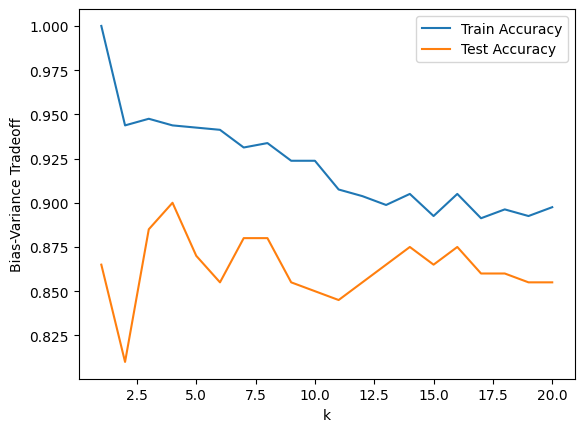

In [19]:
K_values=range(1, 21)
train_acc, test_acc=[], []

for k in K_values:
    model=Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, Y_train)
    train_acc.append(model.score(X_train, Y_train))
    test_acc.append(model.score(X_test, Y_test))

plt.figure()
plt.plot(K_values, train_acc, label="Train Accuracy")
plt.plot(K_values, test_acc, label="Test Accuracy")
plt.xlabel("k")
plt.ylabel("Bias-Variance Tradeoff")
plt.legend()
plt.show()